In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier,
                               BaggingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score, roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)
import time

In [2]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

In [3]:
df = pd.read_csv(r"D:\Sentiment\adult\adult.data",header=None,names = columns, skipinitialspace =True)

In [4]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
print("=" * 50)
print("SHAPE:", df.shape)
print("=" * 50)
print("\nFirst 5 rows:")
print(df.head())

SHAPE: (32561, 15)

First 5 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1       

In [9]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [10]:
df['native_country'].nunique()

42

In [11]:
df['native_country'].value_counts()

native_country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [12]:
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

In [13]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [14]:
df['income'] = (df['income'] == '>50K').astype(int)

In [15]:
print(df['income'].value_counts())
print(f">50K rate: {df['income'].mean():.1%}")

income
0    22633
1     7506
Name: count, dtype: int64
>50K rate: 24.9%


In [16]:
numerical   = ['age', 'education_num', 'capital_gain',
               'capital_loss', 'hours_per_week']
categorical = ['workclass', 'marital_status', 'occupation',
               'relationship', 'race', 'sex']

In [17]:
X = df[numerical + categorical]
y = df['income']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class balance — >50K: {y.mean():.1%}\n")

Train: (24111, 11)  |  Test: (6028, 11)
Class balance — >50K: 24.9%



In [19]:
# ═══════════════════════════════════════════════════════════════
# 2. SHARED PREPROCESSOR
# ═══════════════════════════════════════════════════════════════
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), numerical),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), categorical),
], remainder='drop')

In [20]:
# ═══════════════════════════════════════════════════════════════
# 3. ALL 11 CLASSIFIERS
# ═══════════════════════════════════════════════════════════════
models = {
    # ── Linear models ──────────────────────────────────────────
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        C=1.0, solver='lbfgs', random_state=42
    ),
    'LDA': LinearDiscriminantAnalysis(),

    # ── Tree-based ─────────────────────────────────────────────
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20,
        class_weight='balanced', random_state=42
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200, max_depth=12,
        class_weight='balanced', n_jobs=-1, random_state=42
    ),

    # ── Ensemble ───────────────────────────────────────────────
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        class_weight='balanced', n_jobs=-1, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200, learning_rate=0.5,
        random_state=42, algorithm='SAMME'
    ),
    'Bagging': BaggingClassifier(
        n_estimators=100, n_jobs=-1, random_state=42
    ),

    # ── Other ──────────────────────────────────────────────────
    'KNN': KNeighborsClassifier(
        n_neighbors=15, weights='distance', n_jobs=-1
    ),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(
        kernel='rbf', C=1.0, probability=True,   
        class_weight='balanced', random_state=42
    ),
}


try:
    from xgboost import XGBClassifier
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    models['XGBoost'] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=neg / pos,
        eval_metric='logloss', n_jobs=-1, random_state=42,
        verbosity=0
    )
    print("XGBoost detected and added.")
except ImportError:
    print("XGBoost not found — skipping. Install with: pip install xgboost\n")


try:
    from lightgbm import LGBMClassifier
    models['LightGBM'] = LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        class_weight='balanced', n_jobs=-1, random_state=42,
        verbose=-1
    )
    print("LightGBM detected and added.")
except ImportError:
    print("LightGBM not found — skipping. Install with: pip install lightgbm\n")

XGBoost detected and added.
LightGBM detected and added.


In [21]:
# ═══════════════════════════════════════════════════════════════
# 4. TRAIN ALL MODELS & COLLECT RESULTS
# ═══════════════════════════════════════════════════════════════
print(f"\nTraining {len(models)} models...\n")
results = {}

for name, clf in models.items():
    print(f"  [{name}]", end=' ', flush=True)
    t0 = time.time()

    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])

    try:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        elapsed = time.time() - t0

        results[name] = {
            'pipeline':  pipe,
            'y_pred':    y_pred,
            'y_prob':    y_prob,
            'accuracy':  accuracy_score(y_test, y_pred),
            'bal_acc':   balanced_accuracy_score(y_test, y_pred),
            'f1':        f1_score(y_test, y_pred),
            'f1_macro':  f1_score(y_test, y_pred, average='macro'),
            'auc':       roc_auc_score(y_test, y_prob),
            'pr_auc':    average_precision_score(y_test, y_prob),
            'time':      elapsed,
        }
        print(f"AUC={results[name]['auc']:.4f}  "
              f"F1={results[name]['f1']:.4f}  "
              f"({elapsed:.1f}s)")

    except Exception as e:
        print(f"FAILED — {e}")


Training 13 models...

  [Logistic Regression] AUC=0.8998  F1=0.6758  (0.6s)
  [LDA] AUC=0.8868  F1=0.6308  (0.3s)
  [Decision Tree] AUC=0.8969  F1=0.6719  (0.2s)
  [Extra Trees] AUC=0.8880  F1=0.6396  (0.9s)
  [Random Forest] AUC=0.9093  F1=0.6865  (1.0s)
  [Gradient Boosting] AUC=0.9256  F1=0.7137  (11.6s)
  [AdaBoost] AUC=0.9047  F1=0.6438  (5.0s)
  [Bagging] AUC=0.8970  F1=0.6695  (5.0s)
  [KNN] AUC=0.8681  F1=0.6355  (0.8s)
  [Naive Bayes] AUC=0.8662  F1=0.5931  (0.2s)
  [SVM] AUC=0.9015  F1=0.6893  (161.2s)
  [XGBoost] AUC=0.9242  F1=0.7174  (0.6s)
  [LightGBM] AUC=0.9247  F1=0.7184  (0.6s)


In [22]:
# ═══════════════════════════════════════════════════════════════
# 5. RANKED COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 85)
print("ALL MODELS RANKED BY ROC-AUC")
print("=" * 85)
print(f"{'Rank':<5} {'Model':<22} {'Accuracy':>9} {'Bal Acc':>8} "
      f"{'F1':>6} {'F1-macro':>9} {'ROC-AUC':>8} {'PR-AUC':>7} {'Time':>6}")
print("-" * 85)

ranked = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)
for rank, (name, r) in enumerate(ranked, 1):
    flag = " ◄ BEST" if rank == 1 else ""
    print(f"{rank:<5} {name:<22} {r['accuracy']:>9.4f} {r['bal_acc']:>8.4f} "
          f"{r['f1']:>6.4f} {r['f1_macro']:>9.4f} {r['auc']:>8.4f} "
          f"{r['pr_auc']:>7.4f} {r['time']:>5.1f}s{flag}")


ALL MODELS RANKED BY ROC-AUC
Rank  Model                   Accuracy  Bal Acc     F1  F1-macro  ROC-AUC  PR-AUC   Time
-------------------------------------------------------------------------------------
1     Gradient Boosting         0.8688   0.7980 0.7137    0.8143   0.9256  0.8309  11.6s ◄ BEST
2     LightGBM                  0.8333   0.8402 0.7184    0.8000   0.9247  0.8287   0.6s
3     XGBoost                   0.8344   0.8377 0.7174    0.8002   0.9242  0.8283   0.6s
4     Random Forest             0.8042   0.8231 0.6865    0.7721   0.9093  0.7869   1.0s
5     AdaBoost                  0.8499   0.7480 0.6438    0.7744   0.9047  0.7842   5.0s
6     SVM                       0.8067   0.8248 0.6893    0.7745   0.9015  0.7470 161.2s
7     Logistic Regression       0.8029   0.8102 0.6758    0.7671   0.8998  0.7631   0.6s
8     Bagging                   0.8442   0.7738 0.6695    0.7838   0.8970  0.7749   5.0s
9     Decision Tree             0.7928   0.8126 0.6719    0.7603   0.8969  0

In [23]:
# ═══════════════════════════════════════════════════════════════
# 6. FULL CLASSIFICATION REPORTS
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 85)
print("FULL CLASSIFICATION REPORTS")
print("=" * 85)
for name, r in ranked:
    print(f"\n── {name} ──")
    print(classification_report(y_test, r['y_pred'],
                                target_names=['<=50K', '>50K']))


FULL CLASSIFICATION REPORTS

── Gradient Boosting ──
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      4527
        >50K       0.78      0.66      0.71      1501

    accuracy                           0.87      6028
   macro avg       0.84      0.80      0.81      6028
weighted avg       0.86      0.87      0.86      6028


── LightGBM ──
              precision    recall  f1-score   support

       <=50K       0.94      0.83      0.88      4527
        >50K       0.62      0.85      0.72      1501

    accuracy                           0.83      6028
   macro avg       0.78      0.84      0.80      6028
weighted avg       0.86      0.83      0.84      6028


── XGBoost ──
              precision    recall  f1-score   support

       <=50K       0.94      0.83      0.88      4527
        >50K       0.62      0.84      0.72      1501

    accuracy                           0.83      6028
   macro avg       0.78      0.84      0.80

In [24]:
# ═══════════════════════════════════════════════════════════════
# 7. CROSS-VALIDATION — top 5 models only (CV is slow)
# ═══════════════════════════════════════════════════════════════
print("=" * 85)
print("5-FOLD CROSS-VALIDATION — top 5 models by AUC")
print("=" * 85)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
top5 = [name for name, _ in ranked[:5]]

for name in top5:
    scores = cross_val_score(
        results[name]['pipeline'], X, y,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    print(f"\n{name}")
    print(f"  Folds : {scores.round(4)}")
    print(f"  Mean  : {scores.mean():.4f} ± {scores.std():.4f}")

5-FOLD CROSS-VALIDATION — top 5 models by AUC

Gradient Boosting
  Folds : [0.9276 0.9285 0.9302 0.9185 0.9283]
  Mean  : 0.9266 ± 0.0042

LightGBM
  Folds : [0.929  0.9287 0.9297 0.9192 0.9283]
  Mean  : 0.9270 ± 0.0039

XGBoost
  Folds : [0.9298 0.9277 0.9277 0.919  0.9276]
  Mean  : 0.9264 ± 0.0038

Random Forest
  Folds : [0.9119 0.9186 0.9169 0.9017 0.9113]
  Mean  : 0.9121 ± 0.0059

AdaBoost
  Folds : [0.9078 0.9151 0.9138 0.8976 0.9085]
  Mean  : 0.9086 ± 0.0062


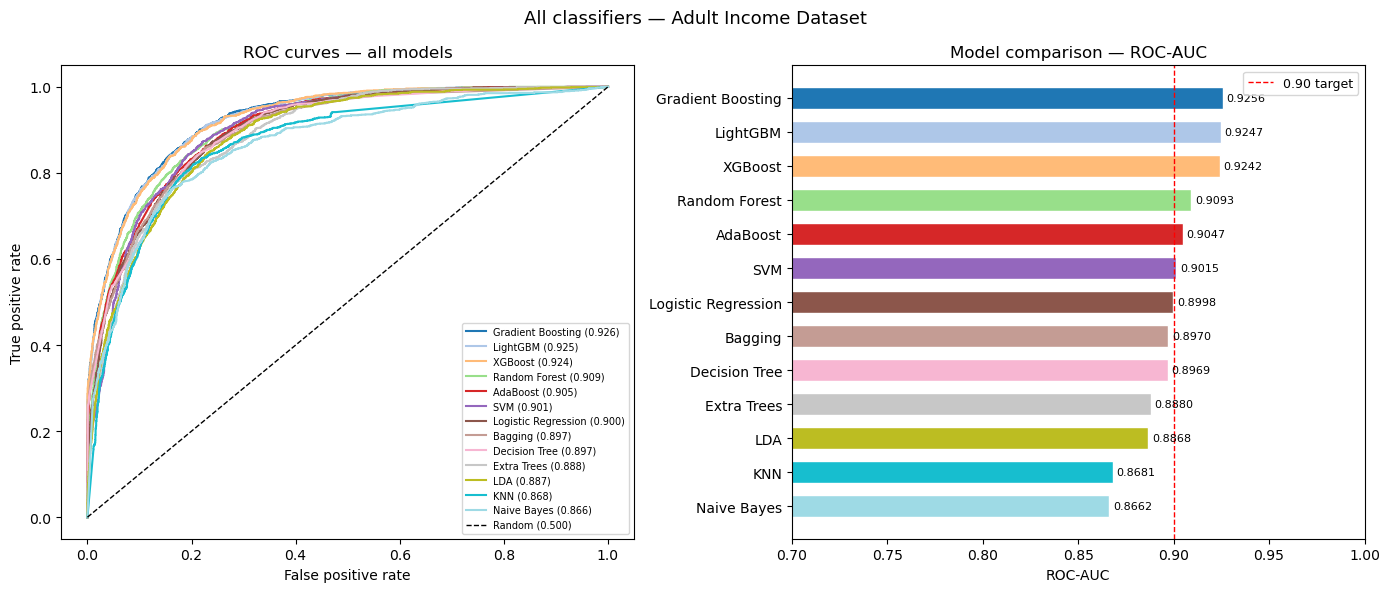

In [25]:
# ═══════════════════════════════════════════════════════════════
# 8. VISUALISATION
# ═══════════════════════════════════════════════════════════════
n_models = len(results)
colors   = plt.cm.tab20(np.linspace(0, 1, n_models))
# ── 8a. ROC curves — all models ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for (name, r), color in zip(ranked, colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} ({r['auc']:.3f})",
            color=color, lw=1.5)
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random (0.500)')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves — all models')
ax.legend(fontsize=7, loc='lower right')
# ── 8b. AUC bar chart ─────────────────────────────────────────
ax2 = axes[1]
names_sorted = [n for n, _ in ranked]
aucs_sorted  = [r['auc'] for _, r in ranked]
bars = ax2.barh(names_sorted[::-1], aucs_sorted[::-1],
                color=colors[::-1], edgecolor='white', height=0.65)
ax2.axvline(0.9, color='red', linestyle='--', lw=1,
            label='0.90 target')
ax2.set_xlabel('ROC-AUC')
ax2.set_title('Model comparison — ROC-AUC')
ax2.set_xlim(0.7, 1.0)
ax2.legend(fontsize=9)
for bar, auc in zip(bars[::-1], aucs_sorted):
    ax2.text(auc + 0.002, bar.get_y() + bar.get_height()/2,
             f'{auc:.4f}', va='center', fontsize=8)

plt.suptitle('All classifiers — Adult Income Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

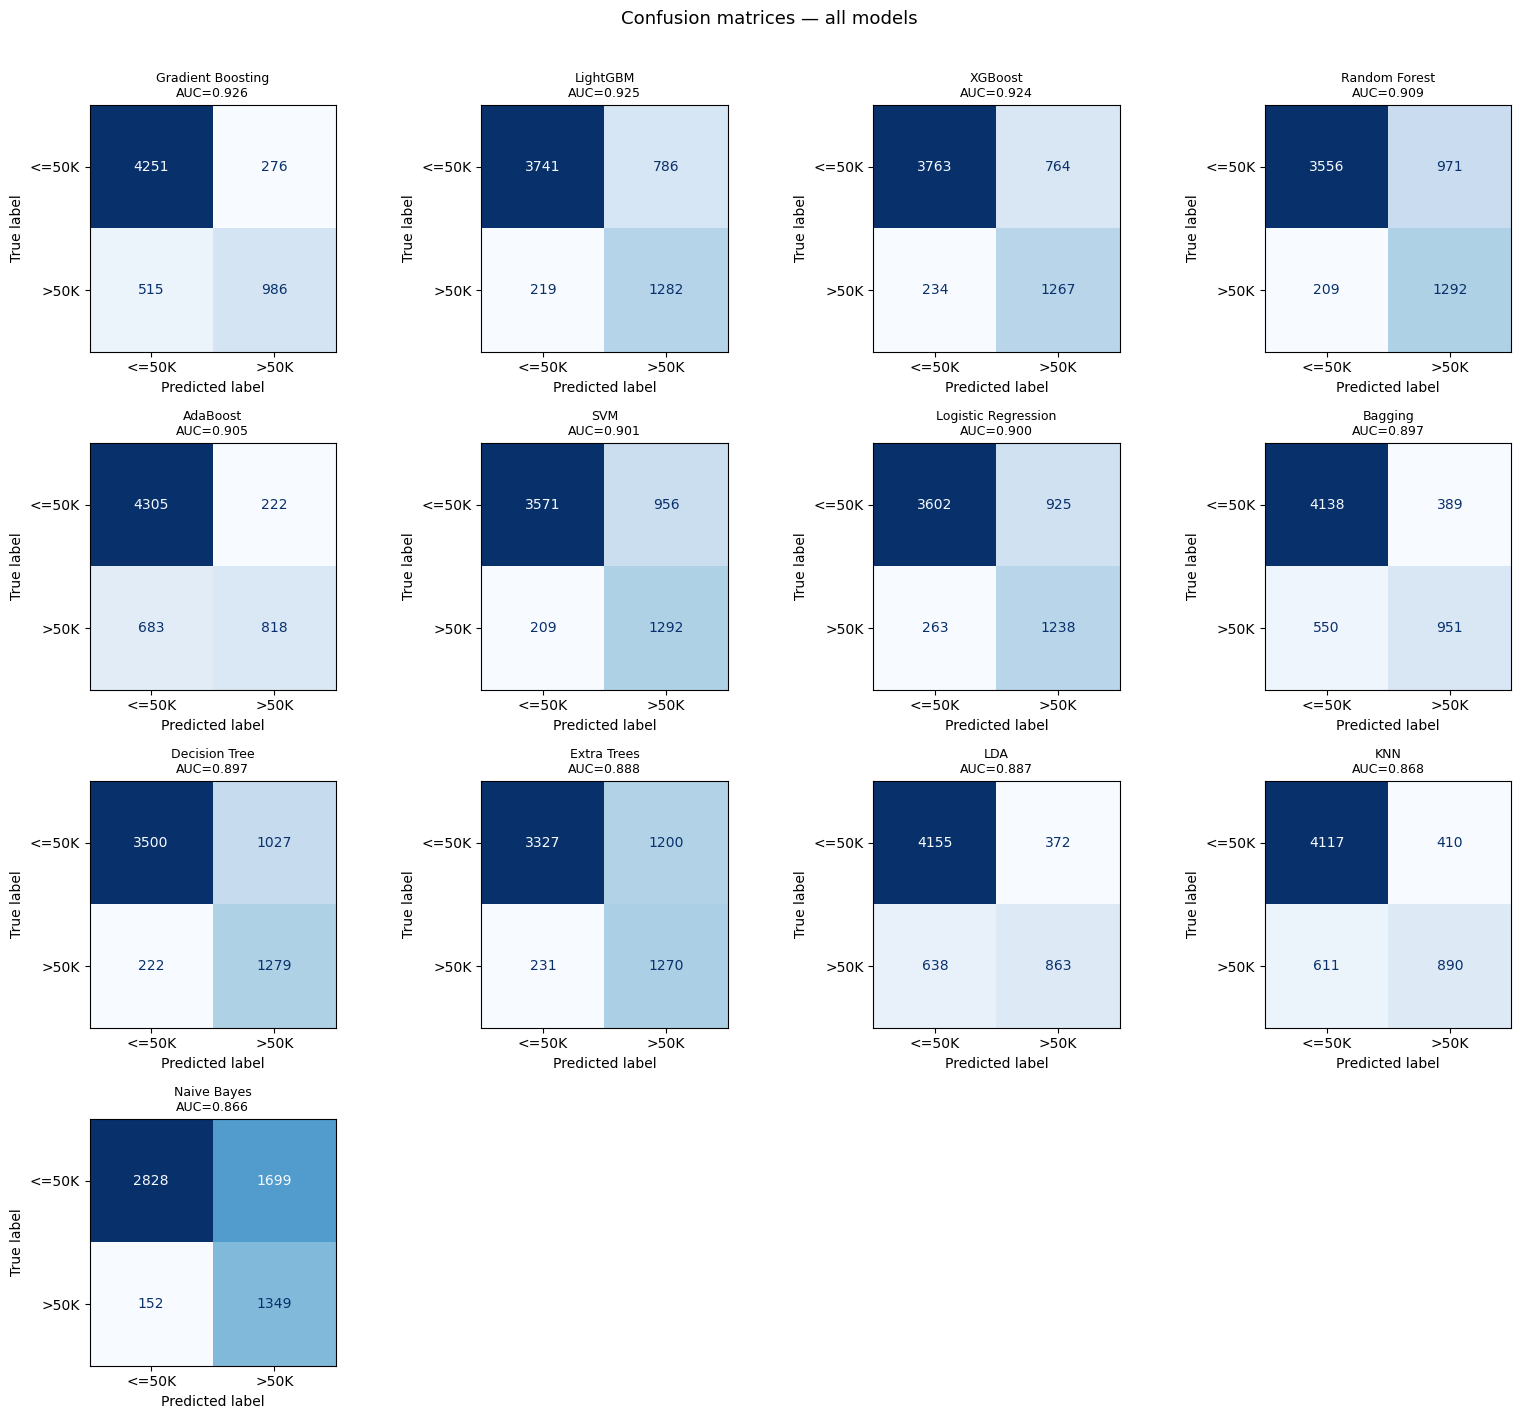

In [26]:
# ── 8c. Confusion matrices — all models in a grid ─────────────
ncols = 4
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for i, (name, r) in enumerate(ranked):
    cm = confusion_matrix(y_test, r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(f"{name}\nAUC={r['auc']:.3f}", fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion matrices — all models', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

In [27]:
# ═══════════════════════════════════════════════════════════════
# 9. BEST MODEL — save + sample prediction
# ═══════════════════════════════════════════════════════════════
import joblib

best_name, best_r = ranked[0]
joblib.dump(best_r['pipeline'], 'best_model.pkl')
print(f"\nBest model : {best_name}  (AUC={best_r['auc']:.4f})")
print(f"Saved to   : best_model.pkl")

new_person = pd.DataFrame([{
    'age': 42, 'education_num': 14, 'capital_gain': 8000,
    'capital_loss': 0, 'hours_per_week': 50,
    'workclass': 'Private', 'marital_status': 'Married-civ-spouse',
    'occupation': 'Exec-managerial', 'relationship': 'Husband',
    'race': 'White', 'sex': 'Male',
}])

model  = joblib.load('best_model.pkl')
pred   = model.predict(new_person)[0]
prob   = model.predict_proba(new_person)[0][1]
print(f"\nSample prediction : {'> 50K' if pred else '<= 50K'}")
print(f"Confidence        : {prob:.1%}")


Best model : Gradient Boosting  (AUC=0.9256)
Saved to   : best_model.pkl

Sample prediction : > 50K
Confidence        : 99.6%


In [29]:
)